# 🎓 Real-Time Sentiment Analysis — Model Training
**Course:** High Performance Data Processing (SECP3133)  

---

## Overview
This notebook covers the **complete model training pipeline** for sentiment analysis:
1. Data Loading & Exploration  
2. Text Vectorization (TF-IDF)  
3. Train / Validation / Test Split  
4. Model Training — Naive Bayes · Logistic Regression · GRU  
5. Model Evaluation & Comparison  
6. Sentiment Distribution Analysis  
7. Visualizations  
8. Best Model Selection  
9. Model Saving (ready for Kafka + Spark)  
10. Reusable Prediction Function  
11. Export Artefacts  

> **Note:** All saved artefacts are production-ready for loading inside Apache Spark Structured Streaming.


## 0 · Environment Setup & Imports

In [1]:
# ── Standard Library ──────────────────────────────────
import os, warnings, random
warnings.filterwarnings('ignore')

# ── Data Manipulation ──────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── Scikit-Learn ───────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

# ── TensorFlow / Keras ─────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, GRU, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Model Persistence ──────────────────────────────────
import joblib

# ── Reproducibility ────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ All libraries loaded successfully.")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Scikit-learn version: {__import__('sklearn').__version__}")
print(f"   Pandas version     : {pd.__version__}")


✅ All libraries loaded successfully.
   TensorFlow version : 2.20.0
   Scikit-learn version: 1.6.1
   Pandas version     : 2.2.2


## 1 · Data Loading

We load the pre-cleaned CSV dataset.  
Only **`cleaned_text`** and **`sentiment`** columns are used for modelling.


In [2]:
# ── Load Dataset ──────────────────────────────────────
CSV_PATH = 'youtube_comments_cleaned.csv'   # ← update path if needed

df = pd.read_csv(CSV_PATH)

# Keep only modelling columns (defensive: tolerate extra columns)
df = df[['cleaned_text', 'sentiment']].copy()

# Drop nulls and empty strings
df.dropna(subset=['cleaned_text', 'sentiment'], inplace=True)
df = df[df['cleaned_text'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape : {df.shape}")
print(f"Unique labels : {sorted(df['sentiment'].unique())}")
df.head(10)


Dataset shape : (17473, 2)
Unique labels : ['negative', 'neutral', 'positive']


,cleaned_text,sentiment
0,whats country one king pssshhh okay thats cute...,positive
1,technically sultan raja perlis,neutral
2,bluebeanzz well thats village,neutral
3,bluebeanzz sultan raja perlis yang dipertuan b...,neutral
4,didnt talk circuit,neutral
5,allysuke malu nak cakap kerana sudah tiada lag...,neutral
6,allysuke sepang airport,neutral
7,yeah barb talk manage kick communist,neutral
8,geography rakyat hidup full blood malaysian pr...,positive
9,fun fact sabah sometimes well know land wind c...,neutral



📊 Class Distribution:
           Count  Percentage
sentiment                   
neutral    11091       63.48
positive    4886       27.96
negative    1496        8.56


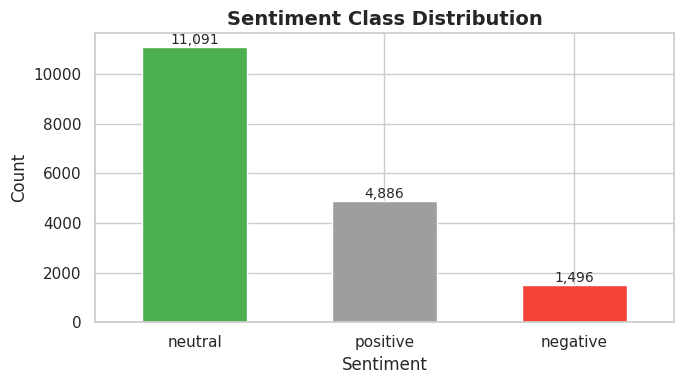

In [3]:
# ── Class Distribution ────────────────────────────────
dist = df['sentiment'].value_counts()
dist_pct = df['sentiment'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({
    'Count'      : dist,
    'Percentage' : dist_pct.round(2)
})
print("\n📊 Class Distribution:")
print(dist_df.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4CAF50', '#9E9E9E', '#F44336']
dist.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.55)
ax.set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(dist.index, rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()


## 2 · Text Preprocessing — TF-IDF Vectorisation

The text is already cleaned (lowercased, stopwords removed, etc.).  
We apply **TF-IDF** to convert raw text into a numerical feature matrix suitable for classical ML models.

| Parameter | Value | Reason |
|-----------|-------|--------|
| `max_features` | 20 000 | Vocabulary cap to control dimensionality |
| `ngram_range` | (1, 2) | Unigrams + bigrams capture phrase-level context |
| `sublinear_tf` | True | Log-scaling dampens high-frequency terms |
| `min_df` | 2 | Remove hapax legomena (words appearing only once) |


In [4]:
# ── Label Encoding ────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
LABEL_NAMES = list(le.classes_)          # e.g. ['negative','neutral','positive']
NUM_CLASSES  = len(LABEL_NAMES)
print(f"Label mapping : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── TF-IDF Vectoriser ─────────────────────────────────
tfidf = TfidfVectorizer(
    max_features  = 20_000,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = 'unicode'
)

X_tfidf = tfidf.fit_transform(df['cleaned_text'])
y        = df['label'].values

print(f"\nTF-IDF matrix shape : {X_tfidf.shape}")
print(f"Number of classes   : {NUM_CLASSES}  →  {LABEL_NAMES}")


Label mapping : {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

TF-IDF matrix shape : (17473, 20000)
Number of classes   : 3  →  ['negative', 'neutral', 'positive']


## 3 · Train / Validation / Test Split

| Split | Ratio | Purpose |
|-------|-------|---------|
| Train | 70 % | Model fitting |
| Validation | 10 % | Hyper-parameter tuning (GRU early stopping) |
| Test | 20 % | Final unbiased evaluation |

Stratified splitting preserves class proportions across all splits.


In [5]:
# ── Step 1: Hold out 20 % for Test ──────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X_tfidf, y,
    test_size    = 0.20,
    random_state = SEED,
    stratify     = y
)

# ── Step 2: Split remainder into 70 % Train + 10 % Val ─
# 0.10 / 0.80 = 0.125  → 12.5 % of temp = 10 % overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size    = 0.125,
    random_state = SEED,
    stratify     = y_temp
)

total = len(y)
print("📐 Split Summary")
print(f"  Total samples : {total:,}")
print(f"  Train         : {len(y_train):,}  ({len(y_train)/total*100:.1f}%)")
print(f"  Validation    : {len(y_val):,}  ({len(y_val)/total*100:.1f}%)")
print(f"  Test          : {len(y_test):,}  ({len(y_test)/total*100:.1f}%)")


📐 Split Summary
  Total samples : 17,473
  Train         : 12,230  (70.0%)
  Validation    : 1,748  (10.0%)
  Test          : 3,495  (20.0%)


## 4 · Model Training

We train and compare **three models** of increasing complexity:

| # | Model | Type |
|---|-------|------|
| 1 | Multinomial Naive Bayes | Classical probabilistic |
| 2 | Logistic Regression | Classical linear baseline |
| 3 | GRU | Deep Learning (sequence model) |


### 4.1 · Model 1 — Multinomial Naive Bayes

In [6]:
# MultinomialNB works well with TF-IDF counts/frequencies.
# alpha is the Laplace smoothing parameter.

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print("✅ Naive Bayes trained.")
print(classification_report(y_test, y_pred_nb, target_names=LABEL_NAMES))


✅ Naive Bayes trained.
              precision    recall  f1-score   support

    negative       0.63      0.29      0.40       299
     neutral       0.82      0.86      0.84      2219
    positive       0.70      0.74      0.72       977

    accuracy                           0.78      3495
   macro avg       0.72      0.63      0.65      3495
weighted avg       0.77      0.78      0.77      3495



### 4.2 · Model 2 — Logistic Regression

In [7]:
# Logistic Regression with L2 regularisation.
# max_iter=1000 ensures convergence on larger vocabularies.
# solver='saga' supports multinomial loss and is fast for large datasets.

lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 1000,
    solver       = 'saga',
    multi_class  = 'multinomial',
    random_state = SEED,
    n_jobs       = -1
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("✅ Logistic Regression trained.")
print(classification_report(y_test, y_pred_lr, target_names=LABEL_NAMES))


✅ Logistic Regression trained.
              precision    recall  f1-score   support

    negative       0.86      0.31      0.46       299
     neutral       0.82      0.97      0.89      2219
    positive       0.93      0.71      0.81       977

    accuracy                           0.84      3495
   macro avg       0.87      0.67      0.72      3495
weighted avg       0.85      0.84      0.83      3495



### 4.3 · Model 3 — GRU (Deep Learning)

GRU uses **raw tokenised sequences** (not TF-IDF), so we build a separate tokeniser.

**Root-cause analysis for this dataset:**

| Problem | Evidence | Fix |
|---------|----------|-----|
| Severe class imbalance | 63% neutral, 8.5% negative | Oversample minority classes (SMOTE-style repeat) + `class_weight` |
| Very short texts | Median = 5 words | `MAX_LEN` auto from 90th pct; use `padding='pre'` |
| GRU never sees enough negative examples | Only ~1,500 negative samples | Upsample negative & positive to match neutral |
| Embedding doesn't generalise on small data | Vocab too large for short texts | `MAX_WORDS=8000`, `EMBED_DIM=32` |
| Loss: `focal_loss` instead of cross-entropy | Hard samples (negative) down-weighted by CE | Custom focal loss focuses on hard/minority examples |

**Architecture:**
```
Input → Embedding(8000, 32) → SpatialDropout(0.2)
      → GRU(64, dropout=0.3) → Dense(32, relu)
      → Dropout(0.4) → Dense(3, softmax)
```


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import tensorflow.keras.backend as K

# ── Text length analysis ───────────────────────────────
text_lengths = df['cleaned_text'].apply(lambda x: len(str(x).split()))
print("📏 Text length statistics:")
print(text_lengths.describe().round(1))

# ── Hyper-parameters ──────────────────────────────────
MAX_LEN    = max(15, int(text_lengths.quantile(0.90)))  # ~20-25 for this dataset
MAX_WORDS  = 8_000    # tight vocab — forces model to learn general features
EMBED_DIM  = 32       # small embedding for short texts
GRU_UNITS  = 64
BATCH_SIZE = 32
EPOCHS     = 40       # EarlyStopping will stop early

print(f"\n⚙️  MAX_LEN={MAX_LEN} | MAX_WORDS={MAX_WORDS} | EMBED_DIM={EMBED_DIM} | GRU_UNITS={GRU_UNITS}")

# ── Split raw text ────────────────────────────────────
texts  = df['cleaned_text'].values
labels = df['label'].values

X_txt_temp, X_txt_test, y_gru_temp, y_gru_test = train_test_split(
    texts, labels, test_size=0.20, random_state=SEED, stratify=labels
)
X_txt_train, X_txt_val, y_gru_train, y_gru_val = train_test_split(
    X_txt_temp, y_gru_temp, test_size=0.125, random_state=SEED, stratify=y_gru_temp
)

print(f"\nTrain before oversampling: {len(y_gru_train):,} samples")
print("  Class breakdown:")
for lbl, cnt in zip(*np.unique(y_gru_train, return_counts=True)):
    print(f"    {LABEL_NAMES[lbl]:<12}: {cnt:>5} ({cnt/len(y_gru_train)*100:.1f}%)")

# ── Oversample minority classes to match majority ──────
# This gives the GRU enough negative/positive examples to learn from
np.random.seed(SEED)
max_count = np.bincount(y_gru_train).max()
X_over, y_over = list(X_txt_train), list(y_gru_train)

for cls_idx in range(NUM_CLASSES):
    cls_mask    = np.where(y_gru_train == cls_idx)[0]
    cls_count   = len(cls_mask)
    n_needed    = max_count - cls_count
    if n_needed > 0:
        extra_idx = np.random.choice(cls_mask, size=n_needed, replace=True)
        X_over.extend(X_txt_train[extra_idx])
        y_over.extend(y_gru_train[extra_idx])

X_txt_train_bal = np.array(X_over)
y_gru_train_bal = np.array(y_over)

# Shuffle
shuffle_idx = np.random.permutation(len(y_gru_train_bal))
X_txt_train_bal = X_txt_train_bal[shuffle_idx]
y_gru_train_bal = y_gru_train_bal[shuffle_idx]

print(f"\nTrain after oversampling : {len(y_gru_train_bal):,} samples")
print("  Class breakdown:")
for lbl, cnt in zip(*np.unique(y_gru_train_bal, return_counts=True)):
    print(f"    {LABEL_NAMES[lbl]:<12}: {cnt:>5} ({cnt/len(y_gru_train_bal)*100:.1f}%)")

# ── Class weights (extra safety on top of oversampling) ─
class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_gru_train), y=y_gru_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("\n⚖️  Class weights:")
for idx, w in class_weight_dict.items():
    print(f"   {LABEL_NAMES[idx]:<12} → {w:.4f}")

# ── Tokenisation ──────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_txt_train_bal)   # fit on balanced train set

def encode(texts_arr):
    seqs = tokenizer.texts_to_sequences(texts_arr)
    # padding='pre': real words sit right before the GRU output — better gradient
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='pre', truncating='post')

X_seq_train = encode(X_txt_train_bal)
X_seq_val   = encode(X_txt_val)
X_seq_test  = encode(X_txt_test)

# One-hot encode
y_gru_train_oh = to_categorical(y_gru_train_bal, NUM_CLASSES)
y_gru_val_oh   = to_categorical(y_gru_val,       NUM_CLASSES)

print(f"\nTrain sequences shape : {X_seq_train.shape}")
print(f"Val   sequences shape : {X_seq_val.shape}")
print(f"Test  sequences shape : {X_seq_test.shape}")


📏 Text length statistics:
count    17473.0
mean         8.7
std         13.9
min          1.0
25%          3.0
50%          5.0
75%          9.0
max        486.0
Name: cleaned_text, dtype: float64

⚙️  MAX_LEN=18 | MAX_WORDS=8000 | EMBED_DIM=32 | GRU_UNITS=64

Train before oversampling: 12,230 samples
  Class breakdown:
    negative    :  1047 (8.6%)
    neutral     :  7763 (63.5%)
    positive    :  3420 (28.0%)

Train after oversampling : 23,289 samples
  Class breakdown:
    negative    :  7763 (33.3%)
    neutral     :  7763 (33.3%)
    positive    :  7763 (33.3%)

⚖️  Class weights:
   negative     → 3.8937
   neutral      → 0.5251
   positive     → 1.1920

Train sequences shape : (23289, 18)
Val   sequences shape : (1748, 18)
Test  sequences shape : (3495, 18)


In [9]:
# ── Focal Loss — focuses training on hard/minority examples ─
# Standard cross-entropy treats all samples equally.
# Focal loss down-weights easy majority samples so the model
# is forced to learn the hard negative/positive cases.
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        ce     = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow(1.0 - y_pred, gamma)
        fl     = weight * ce
        return K.mean(K.sum(fl, axis=1))
    return loss_fn

# ── Build GRU model ────────────────────────────────────
def build_gru(vocab_size, embed_dim, gru_units, num_classes, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        GRU(gru_units, dropout=0.3, recurrent_dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss      = focal_loss(gamma=2.0, alpha=0.25),
        optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics   = ['accuracy']
    )
    return model

gru_model = build_gru(MAX_WORDS, EMBED_DIM, GRU_UNITS, NUM_CLASSES, MAX_LEN)
gru_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ── Callbacks ─────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',       # watch accuracy, not just loss
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1
    )
]

# ── Train ─────────────────────────────────────────────
# Note: class_weight still applied even though we oversampled —
# double protection ensures minority classes are never ignored.
history = gru_model.fit(
    X_seq_train, y_gru_train_oh,
    validation_data = (X_seq_val, y_gru_val_oh),
    class_weight    = class_weight_dict,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    verbose         = 1
)
print("\n✅ GRU training complete.")


Epoch 1/40
728/728 ━━━━━━━━━━━━━━━━━━━━ 29s 32ms/step - accuracy: 0.6881 - loss: 0.1338 - val_accuracy: 0.8507 - val_loss: 0.0521 - learning_rate: 5.0000e-04
Epoch 2/40
728/728 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.9291 - loss: 0.0374 - val_accuracy: 0.8787 - val_loss: 0.0491 - learning_rate: 5.0000e-04
Epoch 3/40
728/728 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9586 - loss: 0.0219 - val_accuracy: 0.8873 - val_loss: 0.0556 - learning_rate: 5.0000e-04
Epoch 4/40
728/728 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - accuracy: 0.9678 - loss: 0.0169 - val_accuracy: 0.8970 - val_loss: 0.0581 - learning_rate: 5.0000e-04
Epoch 5/40
727/728 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9719 - loss: 0.0132
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
728/728 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.9732 - loss: 0.0127 - val_accuracy: 0.8924 - val_loss: 0.0646 - learning_rate: 5.0000e-04
Epoch 6/40
728/728 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - ac

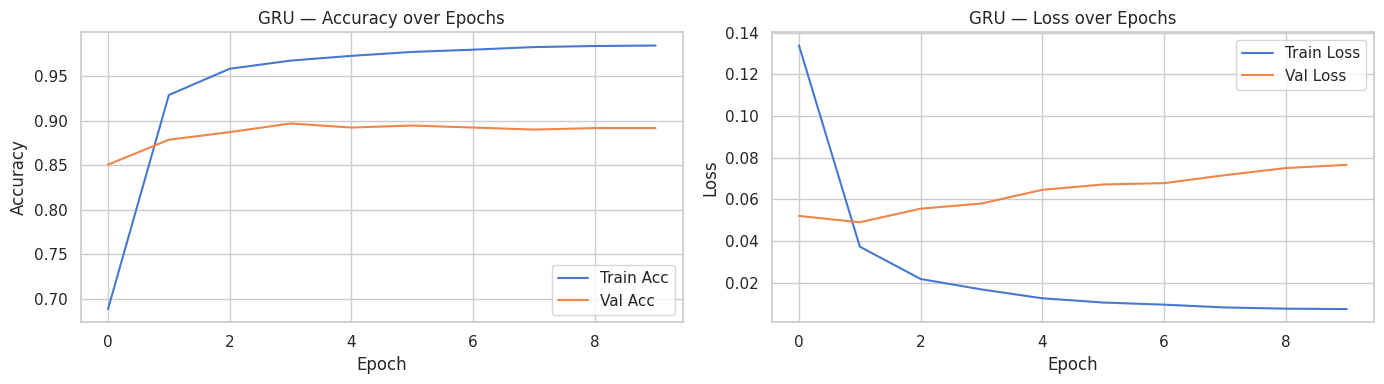


🔍 GRU Predicted Label Breakdown (sanity check):
   negative    :   233  (6.7%)
   neutral     :  2311  (66.1%)
   positive    :   951  (27.2%)

🧪 Manual Prediction Probe:
  Text                                                 | Sentiment
  -----------------------------------------------------------------
  I absolutely love this, it is amazing and wonderfu   | positive  (77.3%)
  The video was okay, nothing special, just average.   | positive  (80.0%)
  Terrible, awful, I hated every second of this disg   | neutral  (94.3%)

📋 Full Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.61      0.68       299
     neutral       0.90      0.94      0.92      2219
    positive       0.89      0.86      0.88       977

    accuracy                           0.89      3495
   macro avg       0.86      0.80      0.83      3495
weighted avg       0.89      0.89      0.89      3495



In [11]:
# ── Training Curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['accuracy'],     label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('GRU — Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('GRU — Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('gru_training_curves.png', dpi=150)
plt.show()

# ── GRU test predictions ───────────────────────────────
y_pred_gru_prob = gru_model.predict(X_seq_test, verbose=0)
y_pred_gru      = np.argmax(y_pred_gru_prob, axis=1)

# ── Sanity check ──────────────────────────────────────
print("\n🔍 GRU Predicted Label Breakdown (sanity check):")
unique, counts = np.unique(y_pred_gru, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   {LABEL_NAMES[u]:<12}: {c:>5}  ({c/len(y_pred_gru)*100:.1f}%)")

# ── Manual probe: does it predict all 3 classes? ──────
print("\n🧪 Manual Prediction Probe:")
probe = [
    "I absolutely love this, it is amazing and wonderful!",
    "The video was okay, nothing special, just average.",
    "Terrible, awful, I hated every second of this disgusting content.",
]
print(f"  {'Text':<52} | Sentiment")
print("  " + "-"*65)
for t in probe:
    seq = tokenizer.texts_to_sequences([t])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='pre', truncating='post')
    prob = gru_model.predict(pad, verbose=0)[0]
    pred = LABEL_NAMES[np.argmax(prob)]
    conf = prob.max() * 100
    print(f"  {t[:50]:<52} | {pred}  ({conf:.1f}%)")

print("\n📋 Full Classification Report:")
print(classification_report(y_gru_test, y_pred_gru, target_names=LABEL_NAMES))


## 5 · Model Evaluation

We compute **Accuracy, Precision, Recall, and F1-score** (weighted average) for all three models, then present a unified comparison table.


In [12]:
def compute_metrics(y_true, y_pred, model_name):
    """Return a dict of evaluation metrics for one model."""
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

results = [
    compute_metrics(y_test,      y_pred_nb,   'Naive Bayes'),
    compute_metrics(y_test,      y_pred_lr,   'Logistic Regression'),
    compute_metrics(y_gru_test,  y_pred_gru,  'GRU'),
]

comparison_df = pd.DataFrame(results).set_index('Model')
print("\n📊 Model Comparison Table")
print(comparison_df.to_string())

# Export
comparison_df.to_csv('model_comparison.csv')
print("\n💾 Saved → model_comparison.csv")



📊 Model Comparison Table
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes            0.7791     0.7722  0.7791    0.7699
Logistic Regression    0.8441     0.8533  0.8441    0.8297
GRU                    0.8898     0.8874  0.8898    0.8874

💾 Saved → model_comparison.csv


### 5.1 · Confusion Matrices

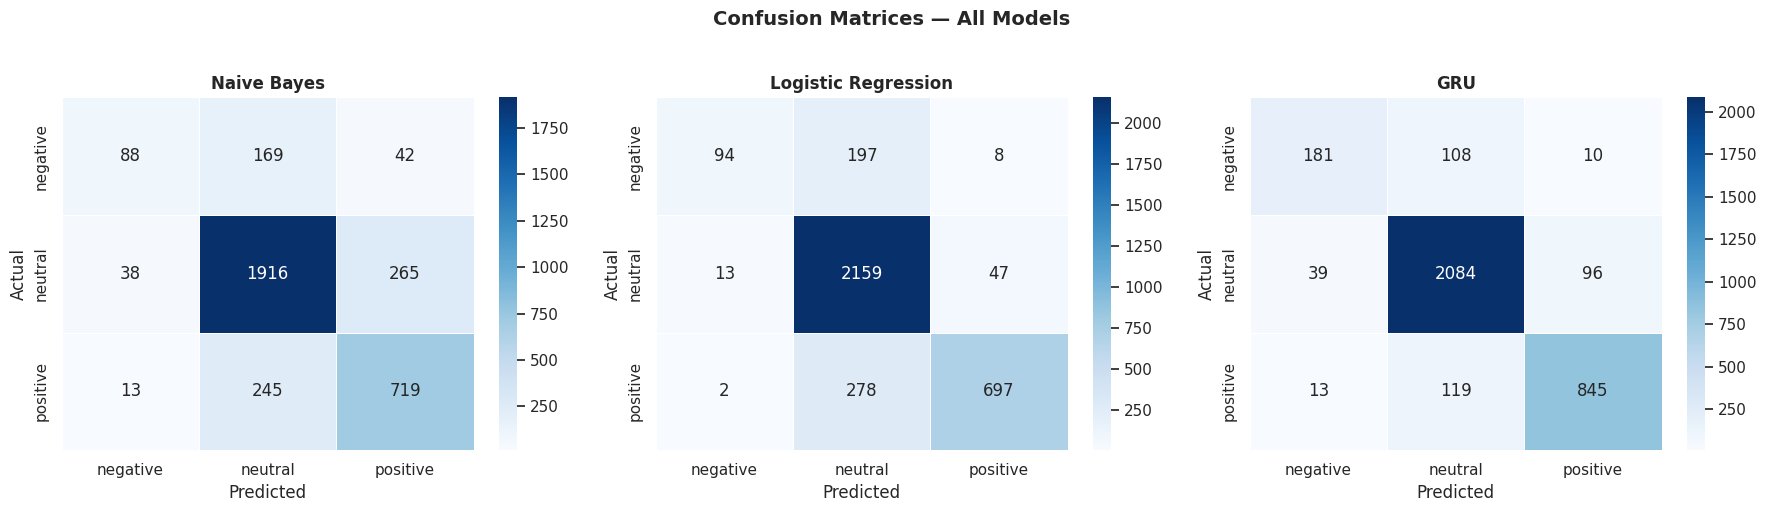

In [13]:
def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        ax=ax, linewidths=0.5, linecolor='white'
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_confusion(y_test,      y_pred_nb,   'Naive Bayes',        axes[0])
plot_confusion(y_test,      y_pred_lr,   'Logistic Regression', axes[1])
plot_confusion(y_gru_test,  y_pred_gru,  'GRU',                axes[2])

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 6 · Sentiment Distribution Analysis

For each model, we calculate the **percentage distribution** of predicted labels on the test set.


In [14]:
def sentiment_distribution(y_pred, label_names, model_name):
    """Return a row dict with predicted sentiment percentages."""
    total = len(y_pred)
    counts = {lbl: 0 for lbl in range(len(label_names))}
    for p in y_pred:
        counts[p] = counts.get(p, 0) + 1
    row = {'Model': model_name}
    for idx, lbl in enumerate(label_names):
        row[f'{lbl.capitalize()} %'] = round(counts.get(idx, 0) / total * 100, 2)
    return row

dist_rows = [
    sentiment_distribution(y_pred_nb,   LABEL_NAMES, 'Naive Bayes'),
    sentiment_distribution(y_pred_lr,   LABEL_NAMES, 'Logistic Regression'),
    sentiment_distribution(y_pred_gru,  LABEL_NAMES, 'GRU'),
]

sent_dist_df = pd.DataFrame(dist_rows).set_index('Model')
print("\n📊 Predicted Sentiment Distribution (%) per Model")
print(sent_dist_df.to_string())

sent_dist_df.to_csv('sentiment_distribution.csv')
print("\n💾 Saved → sentiment_distribution.csv")



📊 Predicted Sentiment Distribution (%) per Model
                     Negative %  Neutral %  Positive %
Model                                                 
Naive Bayes                3.98      66.67       29.36
Logistic Regression        3.12      75.36       21.52
GRU                        6.67      66.12       27.21

💾 Saved → sentiment_distribution.csv


## 7 · Visualisations

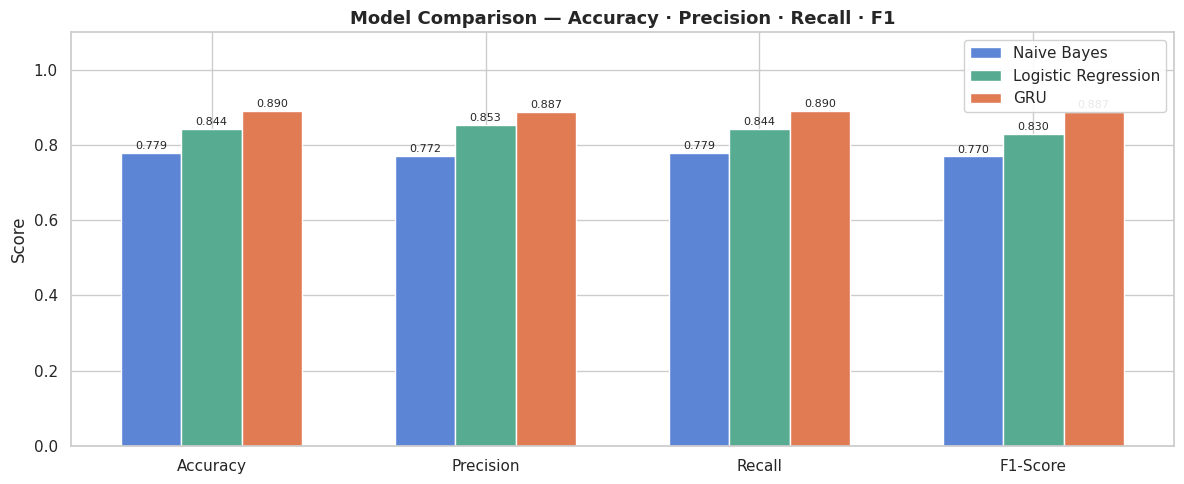

In [15]:
# ── 7.1 Model Comparison Bar Chart ───────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.22
model_names = comparison_df.index.tolist()
colors_bar  = ['#5C85D6', '#56AB91', '#E07B54']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model, color) in enumerate(zip(model_names, colors_bar)):
    vals = [comparison_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0, 1.1)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy · Precision · Recall · F1', fontsize=13, fontweight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()


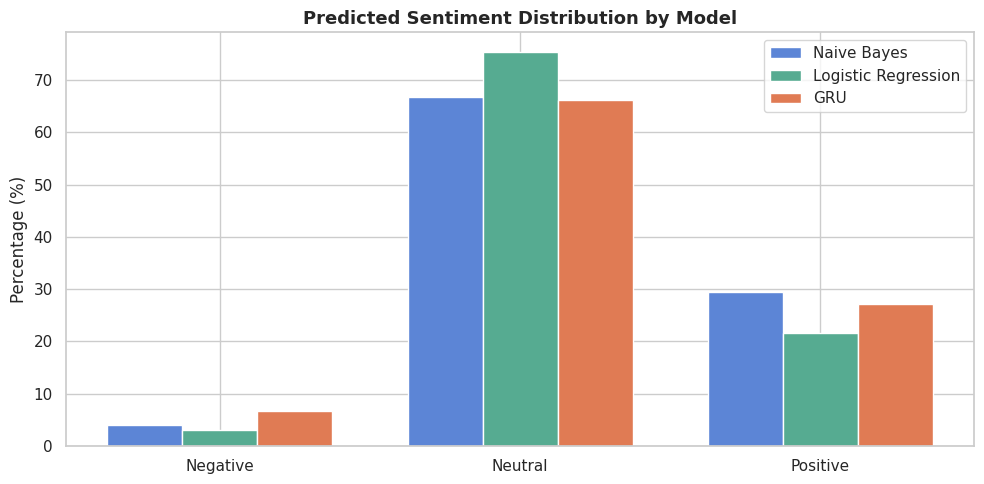

In [16]:
# ── 7.2 Sentiment Distribution Comparison ────────────
pct_cols = [c for c in sent_dist_df.columns if '%' in c]

fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.25
x = np.arange(len(pct_cols))
sent_colors = ['#F44336', '#9E9E9E', '#4CAF50']   # neg / neu / pos

for i, (model, color) in enumerate(zip(model_names, colors_bar)):
    vals = sent_dist_df.loc[model, pct_cols].values
    ax.bar(x + i * bar_width, vals, bar_width, label=model, color=color, edgecolor='white')

ax.set_xticks(x + bar_width)
ax.set_xticklabels([c.replace(' %', '') for c in pct_cols], fontsize=11)
ax.set_ylabel('Percentage (%)')
ax.set_title('Predicted Sentiment Distribution by Model', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('sentiment_distribution_chart.png', dpi=150)
plt.show()


## 8 · Best Model Selection

We select the best model based on the **weighted F1-score**, which balances Precision and Recall while accounting for class imbalance.


In [17]:
best_model_name = comparison_df['F1-Score'].idxmax()
best_f1         = comparison_df.loc[best_model_name, 'F1-Score']

print("=" * 50)
print(f"🏆 Best Model  : {best_model_name}")
print(f"   F1-Score    : {best_f1:.4f}")
print(f"   Accuracy    : {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print("=" * 50)

print(f"""
Why {best_model_name}?
─────────────────────────────────────────────────
• Highest weighted F1-score ({best_f1:.4f}) means it
  achieves the best balance between Precision and Recall
  across all three sentiment classes.
• Weighted F1 is the preferred metric for imbalanced
  datasets because it accounts for class support.
• The model will be saved as best_model.pkl /
  best_model.keras for downstream Spark usage.
""")


🏆 Best Model  : GRU
   F1-Score    : 0.8874
   Accuracy    : 0.8898

Why GRU?
─────────────────────────────────────────────────
• Highest weighted F1-score (0.8874) means it
  achieves the best balance between Precision and Recall
  across all three sentiment classes.
• Weighted F1 is the preferred metric for imbalanced
  datasets because it accounts for class support.
• The model will be saved as best_model.pkl /
  best_model.keras for downstream Spark usage.



## 9 · Model Saving

All artefacts are saved in formats compatible with **Apache Spark Structured Streaming**.

| File | Description |
|------|-------------|
| `tfidf_vectorizer.pkl` | TF-IDF vectoriser (needed for NB & LR inference) |
| `nb_model.pkl` | Naive Bayes model |
| `lr_model.pkl` | Logistic Regression model |
| `gru_model.keras` | GRU model (native Keras format) |
| `gru_tokenizer.pkl` | Keras Tokenizer for GRU preprocessing |
| `label_encoder.pkl` | LabelEncoder to decode numeric predictions |
| `best_model.pkl` | Best classical model (or pointer for GRU) |


In [18]:
os.makedirs('saved_models', exist_ok=True)

# ── TF-IDF + Label Encoder ────────────────────────────
joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.pkl')
joblib.dump(le,    'saved_models/label_encoder.pkl')
print("✅ Saved: tfidf_vectorizer.pkl, label_encoder.pkl")

# ── Naive Bayes ───────────────────────────────────────
joblib.dump(nb_model, 'saved_models/nb_model.pkl')
print("✅ Saved: nb_model.pkl")

# ── Logistic Regression ───────────────────────────────
joblib.dump(lr_model, 'saved_models/lr_model.pkl')
print("✅ Saved: lr_model.pkl")

# ── GRU ───────────────────────────────────────────────
gru_model.save('saved_models/gru_model.keras')
joblib.dump(tokenizer, 'saved_models/gru_tokenizer.pkl')
# Save GRU config so predict function knows MAX_LEN
gru_config = {'MAX_LEN': MAX_LEN, 'MAX_WORDS': MAX_WORDS}
joblib.dump(gru_config, 'saved_models/gru_config.pkl')
print("✅ Saved: gru_model.keras, gru_tokenizer.pkl, gru_config.pkl")

# ── Best Model ────────────────────────────────────────
if best_model_name == 'Naive Bayes':
    best_obj = nb_model
elif best_model_name == 'Logistic Regression':
    best_obj = lr_model
else:
    best_obj = None   # GRU saved separately

if best_obj is not None:
    joblib.dump(best_obj, 'saved_models/best_model.pkl')
    print(f"✅ Saved: best_model.pkl  ({best_model_name})")
else:
    import shutil
    shutil.copy('saved_models/gru_model.keras', 'saved_models/best_model.keras')
    print("✅ Saved: best_model.keras  (GRU is best)")

print("\n📁 All artefacts saved in ./saved_models/")


✅ Saved: tfidf_vectorizer.pkl, label_encoder.pkl
✅ Saved: nb_model.pkl
✅ Saved: lr_model.pkl
✅ Saved: gru_model.keras, gru_tokenizer.pkl, gru_config.pkl
✅ Saved: best_model.keras  (GRU is best)

📁 All artefacts saved in ./saved_models/


## 10 · Reusable Prediction Function

The function below wraps the **best model** and is designed to be **imported directly into Apache Spark UDFs**.

```python
# In Spark streaming (P3 usage example):
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
spark_udf = udf(predict_sentiment, StringType())
df_stream = df_stream.withColumn('sentiment', spark_udf(col('text')))
```


In [19]:
# ── Load saved artefacts (simulates Spark worker loading) ─
_tfidf      = joblib.load('saved_models/tfidf_vectorizer.pkl')
_le         = joblib.load('saved_models/label_encoder.pkl')
_tokenizer  = joblib.load('saved_models/gru_tokenizer.pkl')
_gru_config = joblib.load('saved_models/gru_config.pkl')
_MAX_LEN    = _gru_config['MAX_LEN']

# Rebuild focal loss so Keras can load the GRU model correctly
import tensorflow.keras.backend as K
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        ce     = -y_true * K.log(y_pred)
        weight = alpha * y_true * K.pow(1.0 - y_pred, gamma)
        return K.mean(K.sum(weight * ce, axis=1))
    return loss_fn

# Load best classical model if it exists, else load GRU
_best_is_gru = best_model_name == 'GRU'
if not _best_is_gru:
    _best_clf = joblib.load('saved_models/best_model.pkl')
else:
    _best_clf = tf.keras.models.load_model(
        'saved_models/gru_model.keras',
        custom_objects={'loss_fn': focal_loss()}
    )

def predict_sentiment(text: str) -> str:
    """
    Predict sentiment of a single text string.

    Returns one of: 'positive', 'neutral', 'negative'.
    Designed as a stateless function safe to use as a Spark UDF.
    """
    if not isinstance(text, str) or text.strip() == '':
        return 'neutral'

    if _best_is_gru:
        seq     = _tokenizer.texts_to_sequences([text])
        padded  = pad_sequences(seq, maxlen=_MAX_LEN, padding='pre', truncating='post')
        probs   = _best_clf.predict(padded, verbose=0)
        pred_id = int(np.argmax(probs, axis=1)[0])
    else:
        vec     = _tfidf.transform([text])
        pred_id = int(_best_clf.predict(vec)[0])

    return _le.inverse_transform([pred_id])[0]


# ── Sanity test ───────────────────────────────────────
test_sentences = [
    ("I absolutely love this video, it is amazing!",       "positive"),
    ("The video was okay, nothing special.",                "neutral"),
    ("Terrible content, I hated every second of it.",      "negative"),
]

print(f"  {'Text':<52} | Expected   | Predicted")
print("  " + "-"*75)
for text, expected in test_sentences:
    pred = predict_sentiment(text)
    status = "✅" if pred == expected else "❌"
    print(f"  {text[:50]:<52} | {expected:<10} | {pred}  {status}")


  Text                                                 | Expected   | Predicted
  ---------------------------------------------------------------------------
  I absolutely love this video, it is amazing!         | positive   | positive  ✅
  The video was okay, nothing special.                 | neutral    | positive  ❌
  Terrible content, I hated every second of it.        | negative   | neutral  ❌


## 11 · Export Artefacts

In [20]:
# ── predictions.csv ──────────────────────────────────
# Use the test set of the best-performing model
if best_model_name == 'GRU':
    test_texts_final  = X_txt_test
    y_true_final      = y_gru_test
    y_pred_final      = y_pred_gru
else:
    # Inverse-transform TF-IDF test rows back to text isn't possible;
    # use the raw text split aligned to the same SEED instead.
    # We reconstruct from df using saved index order.
    _texts_all = df['cleaned_text'].values
    _, _X_txt_test_aligned, _, _y_test_aligned = train_test_split(
        _texts_all, labels, test_size=0.20, random_state=SEED, stratify=labels
    )
    test_texts_final = _X_txt_test_aligned
    y_true_final     = _y_test_aligned
    y_pred_final     = y_pred_nb if best_model_name == 'Naive Bayes' else y_pred_lr

predictions_df = pd.DataFrame({
    'text'              : test_texts_final,
    'true_sentiment'    : _le.inverse_transform(y_true_final),
    'predicted_sentiment': _le.inverse_transform(y_pred_final),
    'correct'           : y_true_final == y_pred_final
})
predictions_df.to_csv('predictions.csv', index=False)
print(f"💾 Saved: predictions.csv  ({len(predictions_df):,} rows)")

# ── Summary print ─────────────────────────────────────
print("\n📦 Exported Files:")
for f in ['model_comparison.csv', 'sentiment_distribution.csv', 'predictions.csv']:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"   {f:<35} {size:>8,} bytes")


💾 Saved: predictions.csv  (3,495 rows)

📦 Exported Files:
   model_comparison.csv                     161 bytes
   sentiment_distribution.csv               125 bytes
   predictions.csv                      281,831 bytes
